# Design Challenge 2 - Task 4.3

This notebook completes **Task 4.3 Personalisation and Stability Analysis** for group `15`.

It uses the personal gesture datasets for digits `5` and `6`, mixes them with the original Magic Wand dataset, retrains the baseline CNN architecture, and compares:

- baseline model vs personalised model PC accuracy
- baseline model vs personalised model quantized TFLite accuracy
- prediction stability on repeated personal gestures

## What This Notebook Does

1. Downloads the original baseline digit dataset.
2. Uploads the personal datasets `wanddata_5.json` and `wanddata_6.json`.
3. Builds a **baseline model** using only the original dataset.
4. Builds a **personalised model** by mixing the personal data with the original dataset.
5. Quantizes both models to TensorFlow Lite.
6. Compares:
   - PC-side accuracy on the original baseline test set
   - PC-side accuracy on a personalised mixed test set
   - personal-digit subset accuracy for `5` and `6`
   - prediction consistency on repeated personal gestures
7. Exports CSV summaries and report-ready tables.

In [1]:
%tensorflow_version 2.x

import os
import math
import glob
import json
import shutil
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from IPython.display import display, Image
from google.colab import files

!apt-get update -qq
!apt-get install -y -qq xxd

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
GROUP_ID = 15
PERSONAL_DIGITS = [GROUP_ID % 10, (GROUP_ID % 10) + 1]
PERSONAL_FILENAMES = [f'wanddata_{digit}.json' for digit in PERSONAL_DIGITS]
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('GROUP_ID =', GROUP_ID)
print('Personal digits =', PERSONAL_DIGITS)
print('Expected upload files =', PERSONAL_FILENAMES)

GROUP_ID = 15
Personal digits = [5, 6]
Expected upload files = ['wanddata_5.json', 'wanddata_6.json']


In [3]:
WORK_DIR = Path('/content/dc2_4_3')
ORIG_DIR = WORK_DIR / 'original_dataset'
BASELINE_DATA_DIR = WORK_DIR / 'baseline_split'
PERSONAL_DATA_DIR = WORK_DIR / 'personal_data'
PERSONALISED_DATA_DIR = WORK_DIR / 'personalised_split'
MODELS_DIR = WORK_DIR / 'models'
RESULTS_DIR = WORK_DIR / 'results'
CHKPT_DIR = WORK_DIR / 'checkpoints'

for path in [WORK_DIR, ORIG_DIR, BASELINE_DATA_DIR, PERSONAL_DATA_DIR, PERSONALISED_DATA_DIR, MODELS_DIR, RESULTS_DIR, CHKPT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 30
TRAIN_PERCENTAGE = 100 - TEST_PERCENTAGE - VALIDATION_PERCENTAGE

IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32
BATCH_SIZE = 32
BASELINE_EPOCHS = 30
PERSONALISED_EPOCHS = 30
SCORE_THRESHOLD = 0.0
TRAIN_AUGMENT_COUNT = 10
EVAL_AUGMENT_COUNT = 10

print('Split ratio preserved:', TRAIN_PERCENTAGE, VALIDATION_PERCENTAGE, TEST_PERCENTAGE)

Split ratio preserved: 60 30 10


## Download the Original Baseline Dataset

This follows the same source used in the earlier baseline and `4.2` notebook.

In [4]:
%cd /content
!rm -rf magic_wand_digit_data-* magic_wand_digit_data.zip
!curl -L https://github.com/petewarden/magic_wand_digit_data/archive/8170591863f9addca27b1a963263f7c7bed33f41.zip -o magic_wand_digit_data.zip
!unzip -qq -o magic_wand_digit_data.zip
!rm -rf {ORIG_DIR}
!mkdir -p {ORIG_DIR}
!mv magic_wand_digit_data-*/* {ORIG_DIR}
!rm -rf magic_wand_digit_data-* magic_wand_digit_data.zip

print('Original dataset downloaded to:', ORIG_DIR)

/content
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  238k    0  238k    0     0   205k      0 --:--:--  0:00:01 --:--:-- 9197k
Original dataset downloaded to: /content/dc2_4_3/original_dataset


## Upload the Personal Datasets

Upload the two JSON files from this repository:

- `design-challenge-2/dataset/wanddata_5.json`
- `design-challenge-2/dataset/wanddata_6.json`

In [5]:
uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

for filename in PERSONAL_FILENAMES:
    if filename not in uploaded:
        raise FileNotFoundError(f'Missing required personal dataset file: {filename}')
    (PERSONAL_DATA_DIR / filename).write_bytes(uploaded[filename])

print('Saved uploaded personal datasets to:', PERSONAL_DATA_DIR)

Saving wanddata_5.json to wanddata_5.json
Saving wanddata_6.json to wanddata_6.json
Uploaded files: ['wanddata_5.json', 'wanddata_6.json']
Saved uploaded personal datasets to: /content/dc2_4_3/personal_data


In [6]:
FIXED_POINT = 256


def mul_fp(a, b):
    return (a * b) / FIXED_POINT


def div_fp(a, b):
    if b == 0:
        b = 1
    return (a * FIXED_POINT) / b


def float_to_fp(a):
    return math.floor(a * FIXED_POINT)


def norm_to_coord_fp(a, range_fp, half_size_fp):
    a_fp = float_to_fp(a)
    norm_fp = div_fp(a_fp, range_fp)
    return mul_fp(norm_fp, half_size_fp) + half_size_fp


def round_fp_to_int(a):
    return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)


def gate(a, min_value, max_value):
    if a < min_value:
        return min_value
    if a > max_value:
        return max_value
    return a


def rasterize_stroke(stroke_points, x_range, y_range, width, height):
    num_channels = 3
    buffer_byte_count = height * width * num_channels
    buffer = bytearray(buffer_byte_count)

    width_fp = width * FIXED_POINT
    height_fp = height * FIXED_POINT
    half_width_fp = width_fp / 2
    half_height_fp = height_fp / 2
    x_range_fp = float_to_fp(x_range)
    y_range_fp = float_to_fp(y_range)
    t_inc_fp = FIXED_POINT / len(stroke_points)
    one_half_fp = FIXED_POINT / 2

    for point_index in range(len(stroke_points) - 1):
        start_point = stroke_points[point_index]
        end_point = stroke_points[point_index + 1]
        start_x_fp = norm_to_coord_fp(start_point['x'], x_range_fp, half_width_fp)
        start_y_fp = norm_to_coord_fp(-start_point['y'], y_range_fp, half_height_fp)
        end_x_fp = norm_to_coord_fp(end_point['x'], x_range_fp, half_width_fp)
        end_y_fp = norm_to_coord_fp(-end_point['y'], y_range_fp, half_height_fp)
        delta_x_fp = end_x_fp - start_x_fp
        delta_y_fp = end_y_fp - start_y_fp

        t_fp = point_index * t_inc_fp
        if t_fp < one_half_fp:
            local_t_fp = div_fp(t_fp, one_half_fp)
            one_minus_t_fp = FIXED_POINT - local_t_fp
            red = round_fp_to_int(one_minus_t_fp * 255)
            green = round_fp_to_int(local_t_fp * 255)
            blue = 0
        else:
            local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
            one_minus_t_fp = FIXED_POINT - local_t_fp
            red = 0
            green = round_fp_to_int(one_minus_t_fp * 255)
            blue = round_fp_to_int(local_t_fp * 255)

        red = gate(red, 0, 255)
        green = gate(green, 0, 255)
        blue = gate(blue, 0, 255)

        if abs(delta_x_fp) > abs(delta_y_fp):
            line_length = abs(round_fp_to_int(delta_x_fp))
            if delta_x_fp > 0:
                x_inc_fp = FIXED_POINT
                y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
            else:
                x_inc_fp = -FIXED_POINT
                y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
        else:
            line_length = abs(round_fp_to_int(delta_y_fp))
            if delta_y_fp > 0:
                y_inc_fp = FIXED_POINT
                x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
            else:
                y_inc_fp = -FIXED_POINT
                x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)

        for i in range(line_length + 1):
            x_fp = start_x_fp + (i * x_inc_fp)
            y_fp = start_y_fp + (i * y_inc_fp)
            x = round_fp_to_int(x_fp)
            y = round_fp_to_int(y_fp)
            if (x < 0) or (x >= width) or (y < 0) or (y >= height):
                continue
            buffer_index = (y * width * num_channels) + (x * num_channels)
            buffer[buffer_index + 0] = red
            buffer[buffer_index + 1] = green
            buffer[buffer_index + 2] = blue

    return np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)


X_RANGE = 0.6
Y_RANGE = 0.6


def ensure_empty_dir(dirname):
    dirpath = Path(dirname)
    if dirpath.exists() and dirpath.is_dir():
        shutil.rmtree(dirpath)
    dirpath.mkdir(parents=True, exist_ok=True)


def augment_points(points, move_range, scale_range, rotate_range):
    move_x = np.random.uniform(low=-move_range, high=move_range)
    move_y = np.random.uniform(low=-move_range, high=move_range)
    scale = np.random.uniform(low=1.0 - scale_range, high=1.0 + scale_range)
    rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

    x_axis_x = math.cos(rotate) * scale
    x_axis_y = math.sin(rotate) * scale
    y_axis_x = -math.sin(rotate) * scale
    y_axis_y = math.cos(rotate) * scale

    new_points = []
    for point in points:
        old_x = point['x']
        old_y = point['y']
        new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
        new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
        new_points.append({'x': new_x, 'y': new_y})
    return new_points


def save_strokes_as_images(strokes_subset, root_folder, width, height, augment_count):
    ensure_empty_dir(root_folder)
    labels = sorted({stroke['label'].lower() for stroke in strokes_subset})
    for label in labels:
        Path(root_folder, label).mkdir(parents=True, exist_ok=True)

    for idx, stroke in enumerate(strokes_subset):
        label = stroke['label'].lower()
        raster = rasterize_stroke(stroke['strokePoints'], X_RANGE, Y_RANGE, width, height)
        PIL.Image.fromarray(raster).save(Path(root_folder, label, f'{idx:05d}.png'))

        for aug_idx in range(augment_count):
            raster_aug = rasterize_stroke(
                augment_points(stroke['strokePoints'], 0.08, 0.08, 0.18),
                X_RANGE,
                Y_RANGE,
                width,
                height,
            )
            PIL.Image.fromarray(raster_aug).save(Path(root_folder, label, f'{idx:05d}_aug{aug_idx}.png'))

    return set(labels)


def load_strokes_from_json_dir(json_dir):
    strokes = []
    for filename in sorted(glob.glob(str(Path(json_dir) / '*.json'))):
        with open(filename, 'r') as file:
            file_data = json.load(file)
        for stroke in file_data['strokes']:
            stroke['filename'] = filename
            strokes.append(stroke)
    return strokes


def split_strokes(strokes, seed):
    local = list(strokes)
    rng = random.Random(seed)
    rng.shuffle(local)
    test_count = math.floor((len(local) * TEST_PERCENTAGE) / 100)
    validation_count = math.floor((len(local) * VALIDATION_PERCENTAGE) / 100)
    test_strokes = local[:test_count]
    validation_strokes = local[test_count:test_count + validation_count]
    train_strokes = local[test_count + validation_count:]
    return train_strokes, validation_strokes, test_strokes


def split_personal_by_label(personal_strokes, seed):
    grouped = defaultdict(list)
    for stroke in personal_strokes:
        grouped[stroke['label'].lower()].append(stroke)

    train, val, test = [], [], []
    for offset, label in enumerate(sorted(grouped)):
        label_train, label_val, label_test = split_strokes(grouped[label], seed + offset)
        train.extend(label_train)
        val.extend(label_val)
        test.extend(label_test)
    return train, val, test

In [7]:
original_strokes = load_strokes_from_json_dir(ORIG_DIR)
personal_strokes = load_strokes_from_json_dir(PERSONAL_DATA_DIR)

print('Original strokes:', len(original_strokes))
print('Personal strokes:', len(personal_strokes))
print('Personal label counts:')
print(pd.Series([stroke['label'] for stroke in personal_strokes]).value_counts().sort_index())

Original strokes: 1000
Personal strokes: 46
Personal label counts:
5    20
6    26
Name: count, dtype: int64


## Build the Baseline and Personalised Splits

To keep the comparison fair:

- the original dataset is split using the same ratio as the baseline workflow
- the personal data is split separately with the same ratio per digit
- the personalised dataset is formed by adding the personal train/validation/test subsets into the corresponding original subsets
The image-generation step now mirrors the baseline workflow more closely by applying augmentation when rasterized PNG datasets are created for training, validation, and test folders. This keeps the pipeline aligned with the earlier notebooks and avoids undertraining caused by using too few rasterized examples.


In [8]:
baseline_train_strokes, baseline_val_strokes, baseline_test_strokes = split_strokes(original_strokes, SEED)
personal_train_strokes, personal_val_strokes, personal_test_strokes = split_personal_by_label(personal_strokes, SEED + 100)

personalised_train_strokes = baseline_train_strokes + personal_train_strokes
personalised_val_strokes = baseline_val_strokes + personal_val_strokes
personalised_test_strokes = baseline_test_strokes + personal_test_strokes

print('Baseline split sizes:', len(baseline_train_strokes), len(baseline_val_strokes), len(baseline_test_strokes))
print('Personal split sizes:', len(personal_train_strokes), len(personal_val_strokes), len(personal_test_strokes))
print('Personalised split sizes:', len(personalised_train_strokes), len(personalised_val_strokes), len(personalised_test_strokes))

Baseline split sizes: 600 300 100
Personal split sizes: 29 13 4
Personalised split sizes: 629 313 104


In [9]:
BASELINE_TRAIN_DIR = BASELINE_DATA_DIR / 'train'
BASELINE_VAL_DIR = BASELINE_DATA_DIR / 'validation'
BASELINE_TEST_DIR = BASELINE_DATA_DIR / 'test'

PERSONALISED_TRAIN_DIR = PERSONALISED_DATA_DIR / 'train'
PERSONALISED_VAL_DIR = PERSONALISED_DATA_DIR / 'validation'
PERSONALISED_TEST_DIR = PERSONALISED_DATA_DIR / 'test'

save_strokes_as_images(baseline_train_strokes, BASELINE_TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=TRAIN_AUGMENT_COUNT)
save_strokes_as_images(baseline_val_strokes, BASELINE_VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=EVAL_AUGMENT_COUNT)
save_strokes_as_images(baseline_test_strokes, BASELINE_TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=EVAL_AUGMENT_COUNT)

save_strokes_as_images(personalised_train_strokes, PERSONALISED_TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=TRAIN_AUGMENT_COUNT)
save_strokes_as_images(personalised_val_strokes, PERSONALISED_VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=EVAL_AUGMENT_COUNT)
save_strokes_as_images(personalised_test_strokes, PERSONALISED_TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=EVAL_AUGMENT_COUNT)

{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

In [10]:
def build_dataset_splits(train_dir, val_dir, test_dir):
    train_ds = image_dataset_from_directory(
        directory=train_dir,
        labels='inferred',
        label_mode='categorical',
        batch_size=BATCH_SIZE,
        image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        shuffle=True,
        seed=SEED,
    ).prefetch(buffer_size=32)

    validation_ds = image_dataset_from_directory(
        directory=val_dir,
        labels='inferred',
        label_mode='categorical',
        batch_size=BATCH_SIZE,
        image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        shuffle=False,
    ).prefetch(buffer_size=32)

    test_ds = image_dataset_from_directory(
        directory=test_dir,
        labels='inferred',
        label_mode='categorical',
        batch_size=BATCH_SIZE,
        image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        shuffle=False,
    ).prefetch(buffer_size=32)

    labels = sorted(path.name for path in Path(train_dir).iterdir() if path.is_dir())
    return train_ds, validation_ds, test_ds, labels

baseline_train_ds, baseline_val_ds, baseline_test_ds, labels = build_dataset_splits(
    BASELINE_TRAIN_DIR, BASELINE_VAL_DIR, BASELINE_TEST_DIR
)
personalised_train_ds, personalised_val_ds, personalised_test_ds, personalised_labels = build_dataset_splits(
    PERSONALISED_TRAIN_DIR, PERSONALISED_VAL_DIR, PERSONALISED_TEST_DIR
)

assert labels == personalised_labels
NUM_GESTURES = len(labels)
label_to_int = {label: idx for idx, label in enumerate(labels)}
int_to_label = {idx: label for label, idx in label_to_int.items()}

print('Labels:', labels)
print('NUM_GESTURES =', NUM_GESTURES)

Found 6600 files belonging to 10 classes.
Found 3300 files belonging to 10 classes.
Found 1100 files belonging to 10 classes.
Found 6919 files belonging to 10 classes.
Found 3443 files belonging to 10 classes.
Found 1144 files belonging to 10 classes.
Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
NUM_GESTURES = 10


## Baseline CNN Architecture

Task `4.3` keeps the original Magic Wand baseline CNN structure so that the comparison isolates the effect of adding personal data.

In [11]:
def make_baseline_model(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(16, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='baseline_cnn')

baseline_model_preview = make_baseline_model()
baseline_model_preview.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,986 (58.54 KB)

 Trainable params: 14,826 (57.91 KB)

 Non-trainable params: 160 (640.00 B)

In [12]:
def representative_dataset_from_dir(test_dir):
    for filename in glob.glob(str(Path(test_dir) / '*/*.png')):
        img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        yield [img_array]


def predict_tflite_batch(tflite_model, images_batch):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    outputs = []
    for img_array in images_batch:
        img_array = np.expand_dims(img_array, axis=0)
        input_scale, input_zero_point = input_details['quantization']
        if (input_scale, input_zero_point) != (0.0, 0):
            img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
            img_array = img_array.astype(input_details['dtype'])

        interpreter.set_tensor(input_details['index'], img_array)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details['index'])[0]

        output_scale, output_zero_point = output_details['quantization']
        if (output_scale, output_zero_point) != (0.0, 0):
            pred = pred.astype(np.float32)
            pred = np.multiply((pred - output_zero_point), output_scale)
        outputs.append(pred)

    return np.array(outputs)


def evaluate_quantized_tflite(tflite_model, dataset):
    correct = 0
    total = 0
    for images_batch, labels_batch in dataset:
        preds = predict_tflite_batch(tflite_model, images_batch.numpy())
        pred_idx = np.argmax(preds, axis=1)
        true_idx = np.argmax(labels_batch.numpy(), axis=1)
        correct += np.sum(pred_idx == true_idx)
        total += len(true_idx)
    return float(correct / total) if total else 0.0


def export_c_array(tflite_path, cc_path, variable_name='g_magic_wand_model_data'):
    !xxd -i {tflite_path} > {cc_path}
    replace_text = str(tflite_path).replace('/', '_').replace('.', '_')
    cc_text = Path(cc_path).read_text()
    cc_text = cc_text.replace(replace_text, variable_name)
    Path(cc_path).write_text(cc_text)


def train_and_export(model_name, train_ds, val_ds, eval_test_ds, representative_test_dir, epochs):
    keras.backend.clear_session()
    model = make_baseline_model()
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    checkpoint_path = CHKPT_DIR / f'{model_name}.keras'
    callbacks = [
        keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max'),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    keras_path = MODELS_DIR / f'{model_name}.keras'
    float_tfl_path = MODELS_DIR / f'{model_name}_float.tflite'
    quant_tfl_path = MODELS_DIR / f'{model_name}_quant.tflite'
    cc_path = MODELS_DIR / f'{model_name}.cc'

    model.save(keras_path)

    float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    float_tflite_model = float_converter.convert()
    with open(float_tfl_path, 'wb') as f:
        f.write(float_tflite_model)

    quant_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    quant_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    quant_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    quant_converter.inference_input_type = tf.int8
    quant_converter.inference_output_type = tf.int8
    quant_converter.representative_dataset = lambda: representative_dataset_from_dir(representative_test_dir)
    quant_tflite_model = quant_converter.convert()
    with open(quant_tfl_path, 'wb') as f:
        f.write(quant_tflite_model)

    export_c_array(quant_tfl_path, cc_path)

    pc_test_loss, pc_test_accuracy = model.evaluate(eval_test_ds, verbose=0)
    quant_test_accuracy = evaluate_quantized_tflite(quant_tflite_model, eval_test_ds)

    return {
        'model_name': model_name,
        'model': model,
        'history': history,
        'keras_path': keras_path,
        'quant_tflite_model': quant_tflite_model,
        'quant_tfl_path': quant_tfl_path,
        'pc_test_accuracy_pct': round(pc_test_accuracy * 100, 2),
        'quant_test_accuracy_pct': round(quant_test_accuracy * 100, 2),
        'quant_tflite_size_bytes': os.path.getsize(quant_tfl_path),
    }

## Train the Baseline and Personalised Models

In [13]:
baseline_run = train_and_export(
    model_name='baseline_original',
    train_ds=baseline_train_ds,
    val_ds=baseline_val_ds,
    eval_test_ds=baseline_test_ds,
    representative_test_dir=BASELINE_TEST_DIR,
    epochs=BASELINE_EPOCHS,
)

personalised_run = train_and_export(
    model_name='baseline_personalised',
    train_ds=personalised_train_ds,
    val_ds=personalised_val_ds,
    eval_test_ds=personalised_test_ds,
    representative_test_dir=PERSONALISED_TEST_DIR,
    epochs=PERSONALISED_EPOCHS,
)

print('Training complete.')

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1247 - loss: 0.4472 - val_accuracy: 0.1100 - val_loss: 0.3294
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.1741 - loss: 0.3341 - val_accuracy: 0.1224 - val_loss: 0.3203
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2247 - loss: 0.3171 - val_accuracy: 0.3718 - val_loss: 0.2923
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.2620 - loss: 0.3055 - val_accuracy: 0.5458 - val_loss: 0.2710
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3061 - loss: 0.2948 - val_accuracy: 0.6491 - val_loss: 0.2548
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3359 - loss: 0.2830 - val_accuracy: 0.7106 - val_loss: 0.2395
Epoch 7/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.3655 - loss: 0.2736 - val_accuracy: 0.7821 - val_loss: 0.2269
Epoch 8/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4029 - loss: 0.2629 - val_accu

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.1091 - loss: 0.4774 - val_accuracy: 0.1022 - val_loss: 0.3509
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.1409 - loss: 0.3408 - val_accuracy: 0.1960 - val_loss: 0.3296
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2015 - loss: 0.3237 - val_accuracy: 0.3058 - val_loss: 0.3020
Epoch 4/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.2622 - loss: 0.3071 - val_accuracy: 0.5501 - val_loss: 0.2703
Epoch 5/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.3094 - loss: 0.2922 - val_accuracy: 0.6439 - val_loss: 0.2484
Epoch 6/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.3563 - loss: 0.2799 - val_accuracy: 0.7154 - val_loss: 0.2306
Epoch 7/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4070 - loss: 0.2667 - val_accuracy: 0.5664 - val_loss: 0.2316
Epoch 8/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4443 - loss: 0.2552 - val_a

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Training complete.


In [14]:
def evaluate_subset_accuracy(model, strokes_subset, title):
    rows = []
    for stroke in strokes_subset:
        raster = rasterize_stroke(stroke['strokePoints'], X_RANGE, Y_RANGE, IMAGE_WIDTH, IMAGE_HEIGHT)
        img_array = np.expand_dims(raster.astype(np.float32), axis=0)
        predictions = model.predict(img_array, verbose=0).flatten()
        pred_idx = int(np.argmax(predictions))
        pred_label = int_to_label[pred_idx]
        rows.append({
            'true_label': stroke['label'].lower(),
            'pred_label': pred_label,
            'confidence': float(predictions[pred_idx]),
            'index': stroke.get('index'),
        })

    df = pd.DataFrame(rows)
    accuracy = float((df['true_label'] == df['pred_label']).mean()) if len(df) else 0.0
    print(title, 'accuracy =', round(accuracy * 100, 2), '%')
    return df, accuracy

baseline_personal_df, baseline_personal_acc = evaluate_subset_accuracy(
    baseline_run['model'], personal_strokes, 'Baseline model on personal repeated gestures'
)
personalised_personal_df, personalised_personal_acc = evaluate_subset_accuracy(
    personalised_run['model'], personal_strokes, 'Personalised model on personal repeated gestures'
)

Baseline model on personal repeated gestures accuracy = 52.17 %
Personalised model on personal repeated gestures accuracy = 95.65 %


## Consistency Metric

This notebook defines a simple repeat-consistency metric for each personal digit:

- collect all repeated recordings of the same digit
- run inference on every repetition
- find the **modal predicted label**
- compute consistency as:

`consistency = (number of predictions equal to the modal prediction) / (total repetitions)`

The overall consistency score is the mean of the per-digit consistencies.

This is useful because the coursework asks for a stability-oriented metric rather than accuracy alone.

In [15]:
def consistency_from_prediction_df(df):
    rows = []
    for true_label, group in df.groupby('true_label'):
        pred_counts = group['pred_label'].value_counts()
        modal_label = pred_counts.index[0]
        modal_count = int(pred_counts.iloc[0])
        total = int(len(group))
        consistency = modal_count / total if total else 0.0
        accuracy = float((group['true_label'] == group['pred_label']).mean()) if total else 0.0
        rows.append({
            'digit': true_label,
            'samples': total,
            'modal_prediction': modal_label,
            'modal_count': modal_count,
            'consistency_pct': round(consistency * 100, 2),
            'accuracy_pct': round(accuracy * 100, 2),
        })

    result_df = pd.DataFrame(rows).sort_values('digit')
    overall_consistency = result_df['consistency_pct'].mean() if len(result_df) else 0.0
    return result_df, overall_consistency

baseline_consistency_df, baseline_overall_consistency = consistency_from_prediction_df(baseline_personal_df)
personalised_consistency_df, personalised_overall_consistency = consistency_from_prediction_df(personalised_personal_df)

print('Baseline overall consistency (%):', round(baseline_overall_consistency, 2))
print('Personalised overall consistency (%):', round(personalised_overall_consistency, 2))

Baseline overall consistency (%): 53.08
Personalised overall consistency (%): 96.16


In [16]:
comparison_rows = [
    {
        'model_variant': 'baseline_original',
        'pc_accuracy_original_test_pct': baseline_run['pc_test_accuracy_pct'],
        'quant_accuracy_original_test_pct': baseline_run['quant_test_accuracy_pct'],
        'personal_subset_accuracy_pct': round(baseline_personal_acc * 100, 2),
        'personal_consistency_pct': round(baseline_overall_consistency, 2),
        'quant_tflite_size_bytes': baseline_run['quant_tflite_size_bytes'],
    },
    {
        'model_variant': 'baseline_personalised',
        'pc_accuracy_original_test_pct': '',
        'quant_accuracy_original_test_pct': '',
        'personal_subset_accuracy_pct': round(personalised_personal_acc * 100, 2),
        'personal_consistency_pct': round(personalised_overall_consistency, 2),
        'quant_tflite_size_bytes': personalised_run['quant_tflite_size_bytes'],
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,model_variant,pc_accuracy_original_test_pct,quant_accuracy_original_test_pct,personal_subset_accuracy_pct,personal_consistency_pct,quant_tflite_size_bytes
0,baseline_original,93.73,93.82,52.17,53.08,21288
1,baseline_personalised,,,95.65,96.16,21288


In [17]:
# Evaluate both models on both test sets for fair side-by-side comparison.

def evaluate_model_on_dataset(model, dataset, name):
    _, acc = model.evaluate(dataset, verbose=0)
    return round(acc * 100, 2)

side_by_side_df = pd.DataFrame([
    {
        'model_variant': 'baseline_original',
        'pc_accuracy_on_original_test_pct': evaluate_model_on_dataset(baseline_run['model'], baseline_test_ds, 'baseline on original'),
        'pc_accuracy_on_personalised_test_pct': evaluate_model_on_dataset(baseline_run['model'], personalised_test_ds, 'baseline on personalised'),
        'quant_accuracy_on_original_test_pct': round(evaluate_quantized_tflite(baseline_run['quant_tflite_model'], baseline_test_ds) * 100, 2),
        'quant_accuracy_on_personalised_test_pct': round(evaluate_quantized_tflite(baseline_run['quant_tflite_model'], personalised_test_ds) * 100, 2),
        'personal_repetition_accuracy_pct': round(baseline_personal_acc * 100, 2),
        'personal_consistency_pct': round(baseline_overall_consistency, 2),
    },
    {
        'model_variant': 'baseline_personalised',
        'pc_accuracy_on_original_test_pct': evaluate_model_on_dataset(personalised_run['model'], baseline_test_ds, 'personalised on original'),
        'pc_accuracy_on_personalised_test_pct': evaluate_model_on_dataset(personalised_run['model'], personalised_test_ds, 'personalised on personalised'),
        'quant_accuracy_on_original_test_pct': round(evaluate_quantized_tflite(personalised_run['quant_tflite_model'], baseline_test_ds) * 100, 2),
        'quant_accuracy_on_personalised_test_pct': round(evaluate_quantized_tflite(personalised_run['quant_tflite_model'], personalised_test_ds) * 100, 2),
        'personal_repetition_accuracy_pct': round(personalised_personal_acc * 100, 2),
        'personal_consistency_pct': round(personalised_overall_consistency, 2),
    },
])

side_by_side_df

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model_variant,pc_accuracy_on_original_test_pct,pc_accuracy_on_personalised_test_pct,quant_accuracy_on_original_test_pct,quant_accuracy_on_personalised_test_pct,personal_repetition_accuracy_pct,personal_consistency_pct
0,baseline_original,93.73,91.96,93.82,91.87,52.17,53.08
1,baseline_personalised,91.91,90.65,91.82,90.30,95.65,96.16


<Figure size 700x400 with 0 Axes>

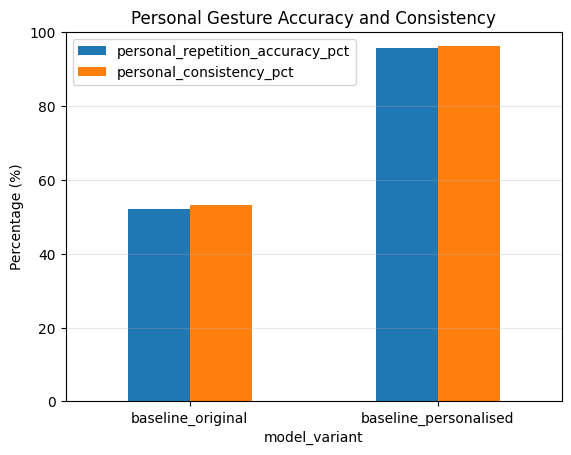

In [18]:
plt.figure(figsize=(7, 4))
plot_df = side_by_side_df[['model_variant', 'personal_repetition_accuracy_pct', 'personal_consistency_pct']].copy()
plot_df = plot_df.set_index('model_variant')
plot_df.plot(kind='bar', ylim=(0, 100), rot=0)
plt.ylabel('Percentage (%)')
plt.title('Personal Gesture Accuracy and Consistency')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [19]:
side_by_side_df.to_csv(RESULTS_DIR / 'task_4_3_comparison.csv', index=False)
baseline_consistency_df.to_csv(RESULTS_DIR / 'task_4_3_baseline_consistency.csv', index=False)
personalised_consistency_df.to_csv(RESULTS_DIR / 'task_4_3_personalised_consistency.csv', index=False)

print('Saved results to:', RESULTS_DIR)
print('Files:')
for path in sorted(RESULTS_DIR.glob('*')):
    print('-', path.name)

Saved results to: /content/dc2_4_3/results
Files:
- task_4_3_baseline_consistency.csv
- task_4_3_comparison.csv
- task_4_3_personalised_consistency.csv


## Suggested Report Points

For Task `4.3`, the report can now include:

- baseline model vs personalised model accuracy comparison
- numerical consistency metric for repeated gestures `5` and `6`
- short explanation of whether personalisation improved recognition of the user's own gestures
- comment on any trade-off between personalisation gains and generalisation to the original dataset

In [20]:
files.download(str(RESULTS_DIR / 'task_4_3_comparison.csv'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>